# **Home Loan Project** ##

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
app_train=pd.read_csv("D:\\project testing\\PRCP-1006-HomeLoanDef\\Data\\application_train.csv")
bureau=pd.read_csv("D:\\project testing\\PRCP-1006-HomeLoanDef\\Data\\bureau.csv")
bureau_balance=pd.read_csv("D:\\project testing\\PRCP-1006-HomeLoanDef\\Data\\bureau_balance.csv")
credit_card=pd.read_csv("D:\\project testing\\PRCP-1006-HomeLoanDef\\Data\\credit_card_balance.csv")
installments=pd.read_csv("D:\\project testing\\PRCP-1006-HomeLoanDef\\Data\\installments_payments.csv")
pos=pd.read_csv("D:\\project testing\\PRCP-1006-HomeLoanDef\\Data\\POS_CASH_balance.csv")
prev_app=pd.read_csv("D:\\project testing\\PRCP-1006-HomeLoanDef\\Data\\previous_application.csv")

In [3]:
app_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## **Basic Checks** ##

In [4]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
app_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
app_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [7]:
app_train.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [8]:
app_train.isnull().sum().sort_values(ascending=False).head(20)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
FLOORSMIN_AVG               208642
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_MEDI            204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
LANDAREA_AVG                182590
dtype: int64

## **Data Analysis** ##

In [9]:
threshold=len(app_train)*0.4
app_train=app_train.dropna(thresh=threshold,axis=1)

In [10]:
num_cols=app_train.select_dtypes(include=['float64','int64']).columns
cat_cols=app_train.select_dtypes(include=['object']).columns

In [11]:
for col in num_cols:
    if app_train[col].isnull().sum()>0:
        app_train.loc[:,col]=app_train[col].fillna(app_train[col].median())

In [12]:
for col in cat_cols:
    if app_train[col].isnull().sum()>0:
        app_train.loc[:,col]=app_train[col].fillna(app_train[col].mode()[0])

In [13]:
app_train.isnull().sum().sum()

0

In [14]:
app_train.isnull().sum()

SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 105, dtype: int64

In [15]:
app_train.shape

(307511, 105)

In [16]:
app_train.dtypes.value_counts()

float64    49
int64      41
object     15
Name: count, dtype: int64

## **Data Visualization** ##

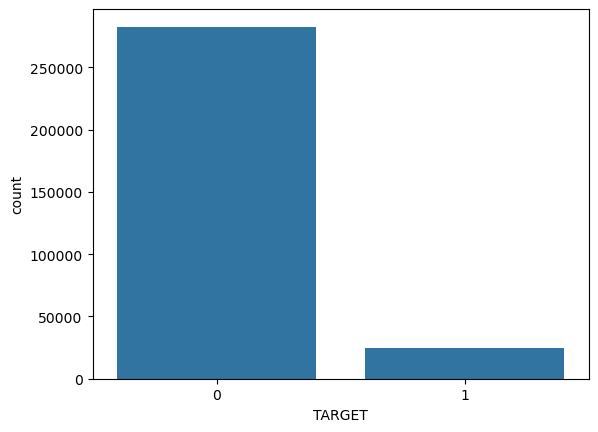

In [17]:
sns.countplot(data=app_train,x='TARGET')
plt.show()

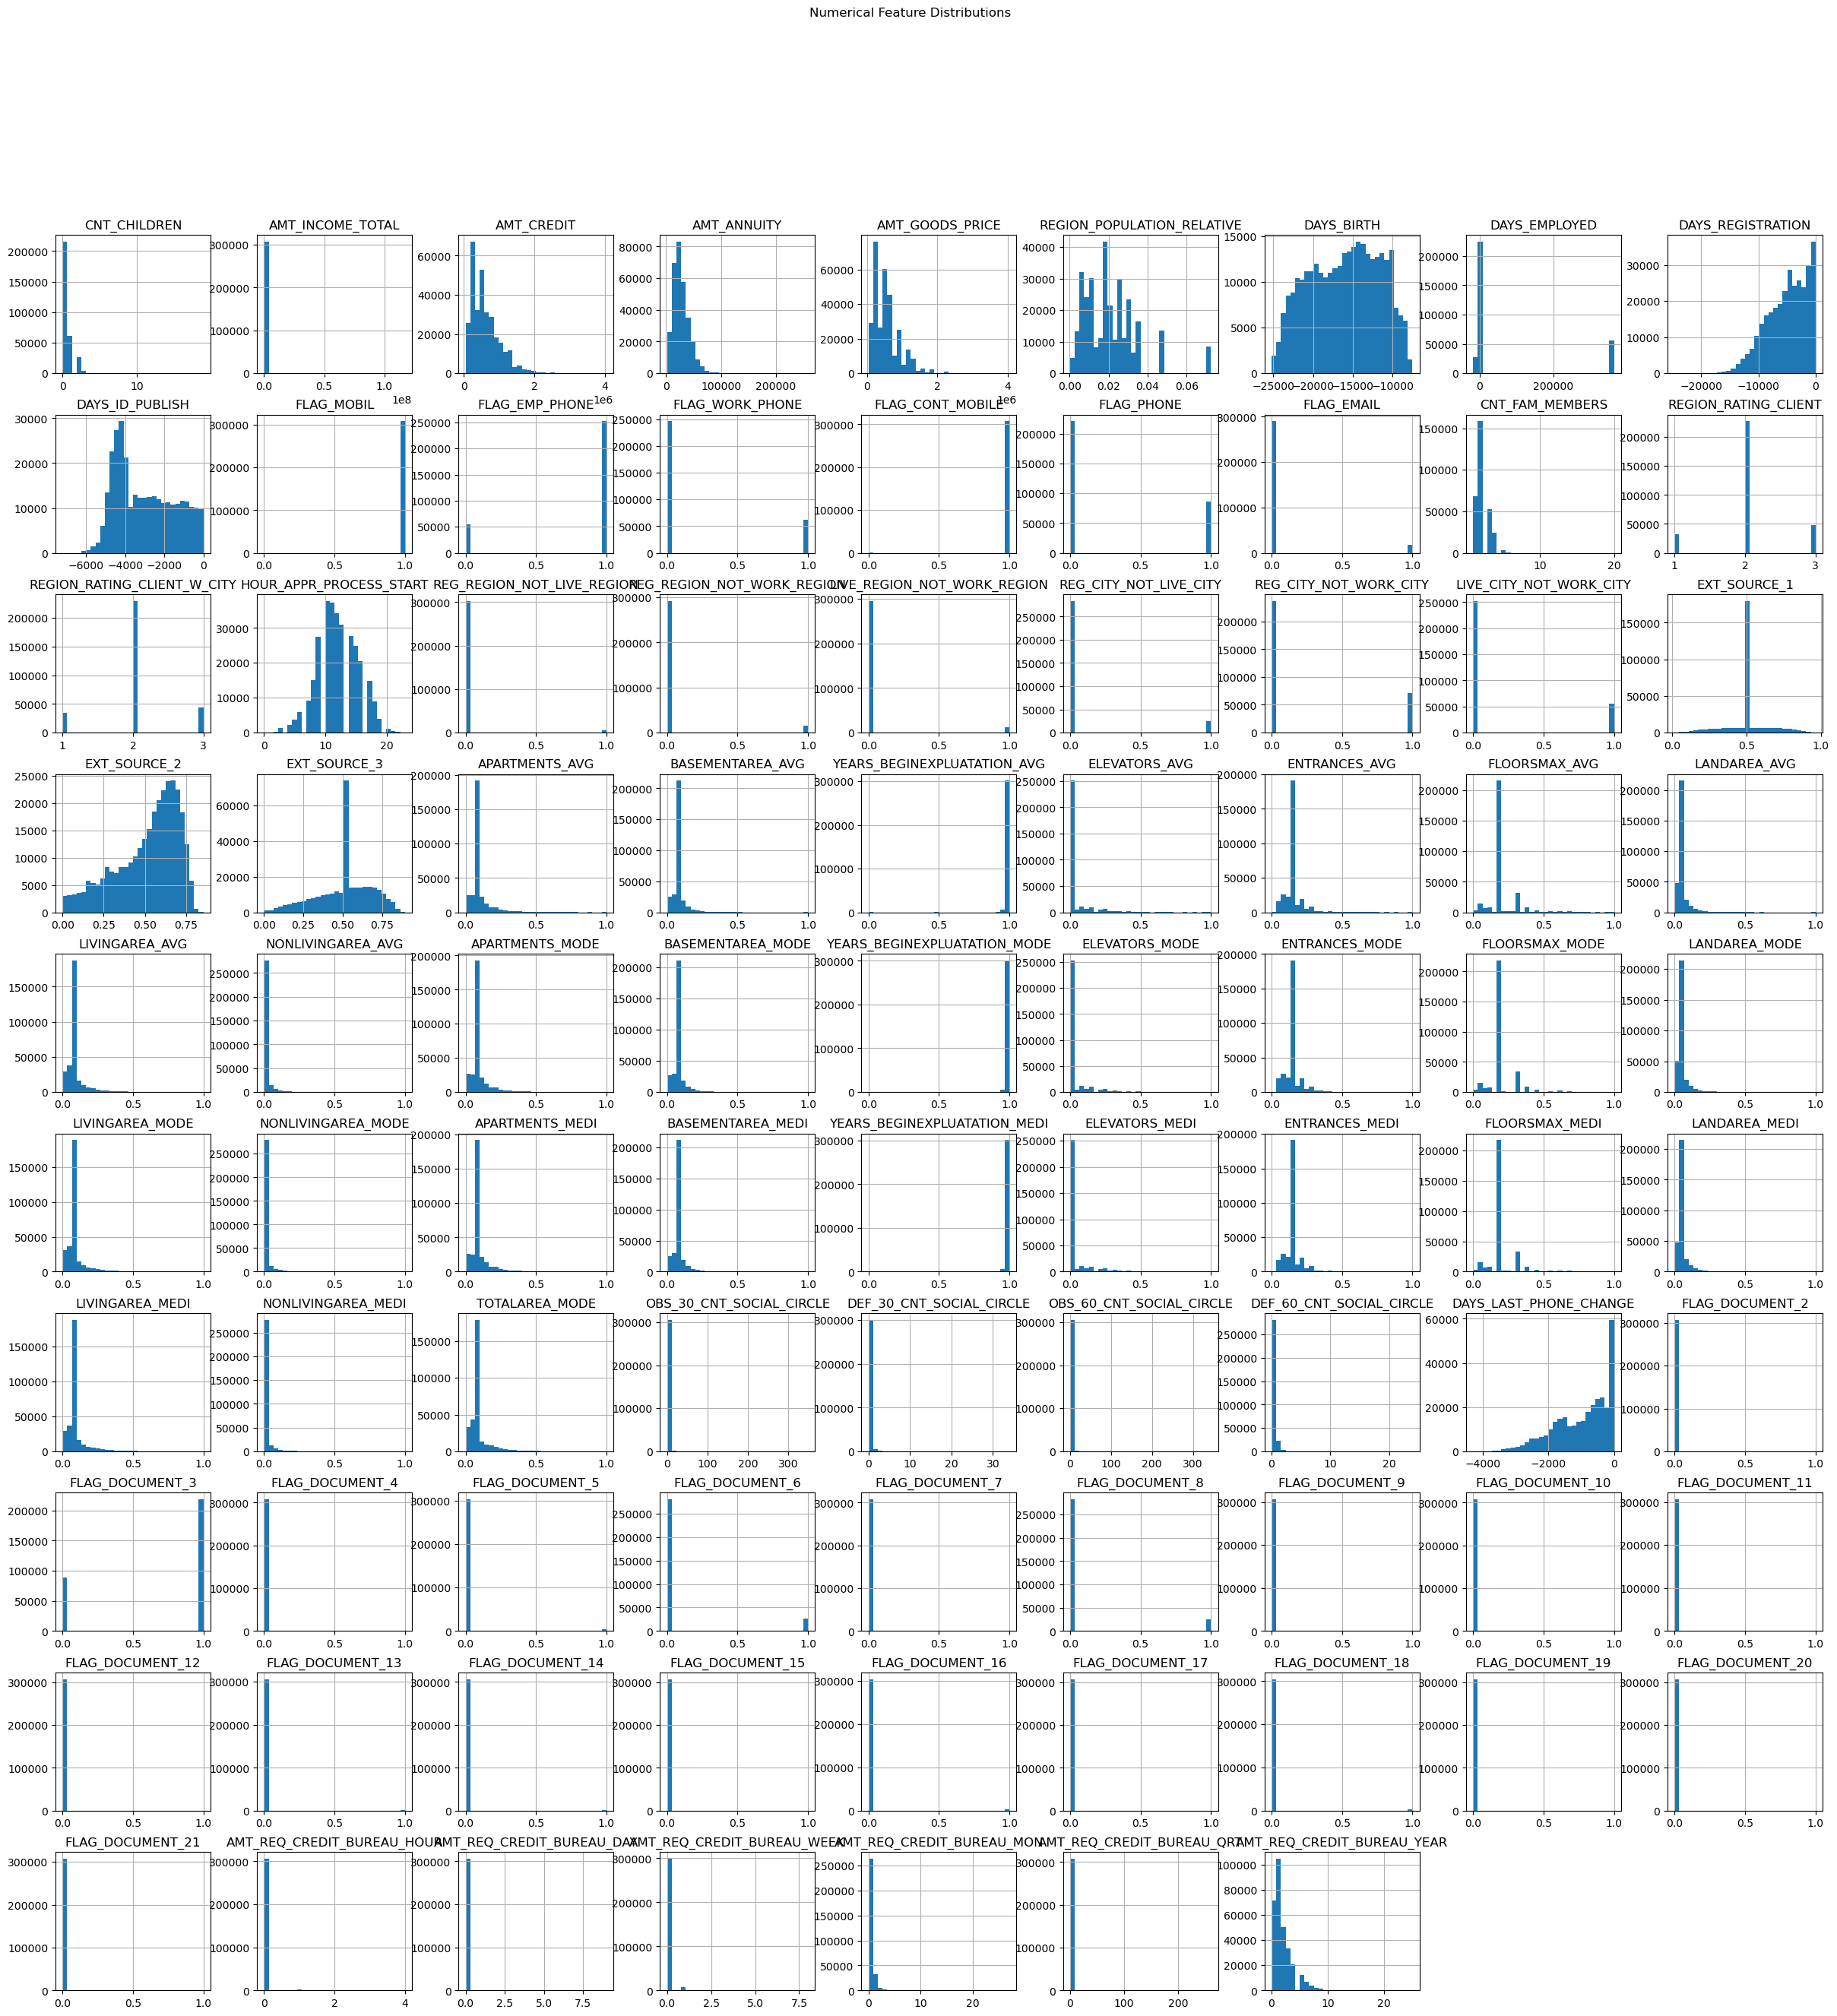

In [18]:
num_cols=app_train.select_dtypes(include=['int64','float64']).columns.drop(['TARGET','SK_ID_CURR'])
app_train[num_cols].hist(figsize=(30,30),bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.show()

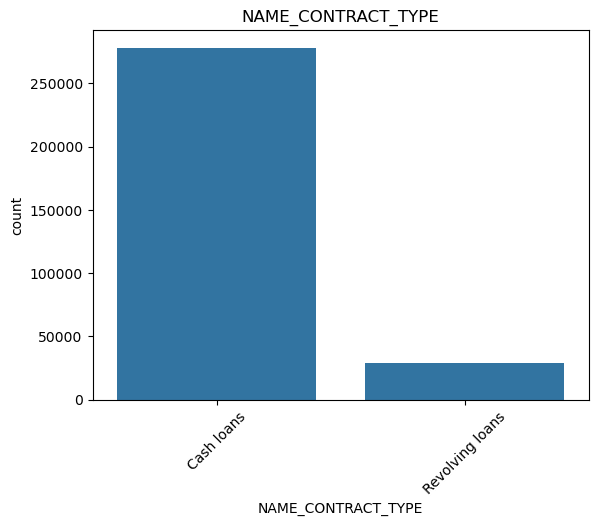

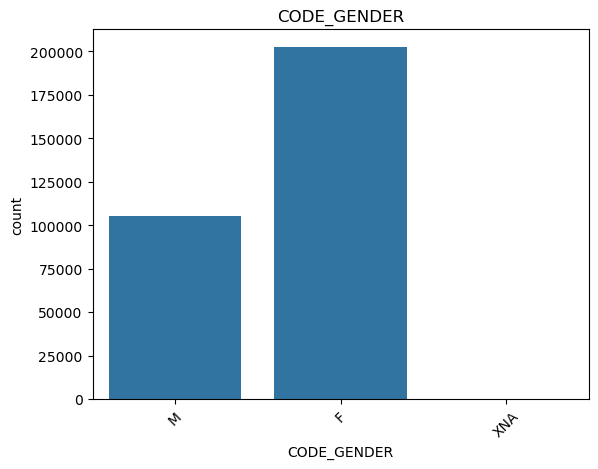

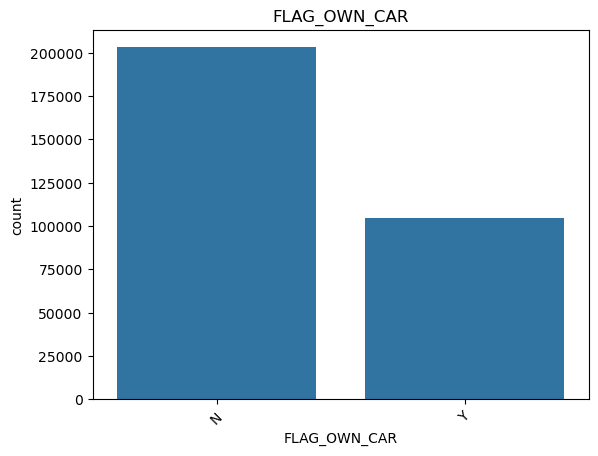

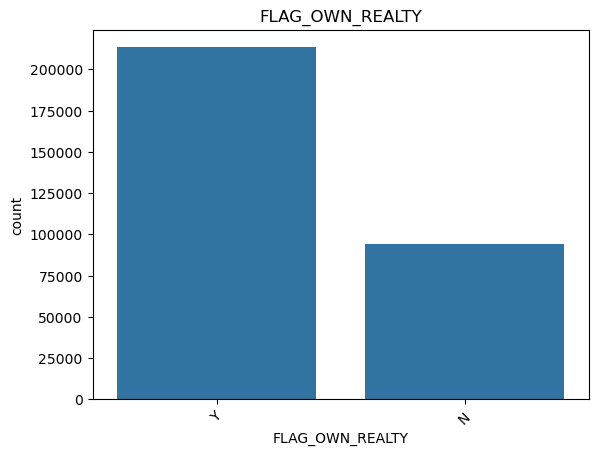

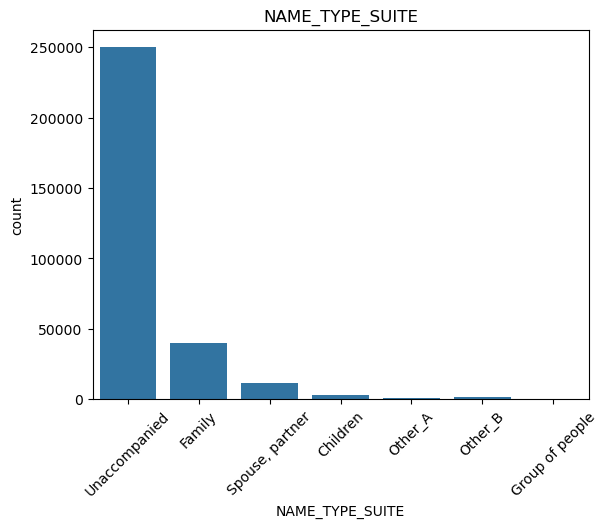

In [19]:
cat_cols=app_train.select_dtypes(include='object').columns
for col in cat_cols[:5]:
    sns.countplot(data=app_train,x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

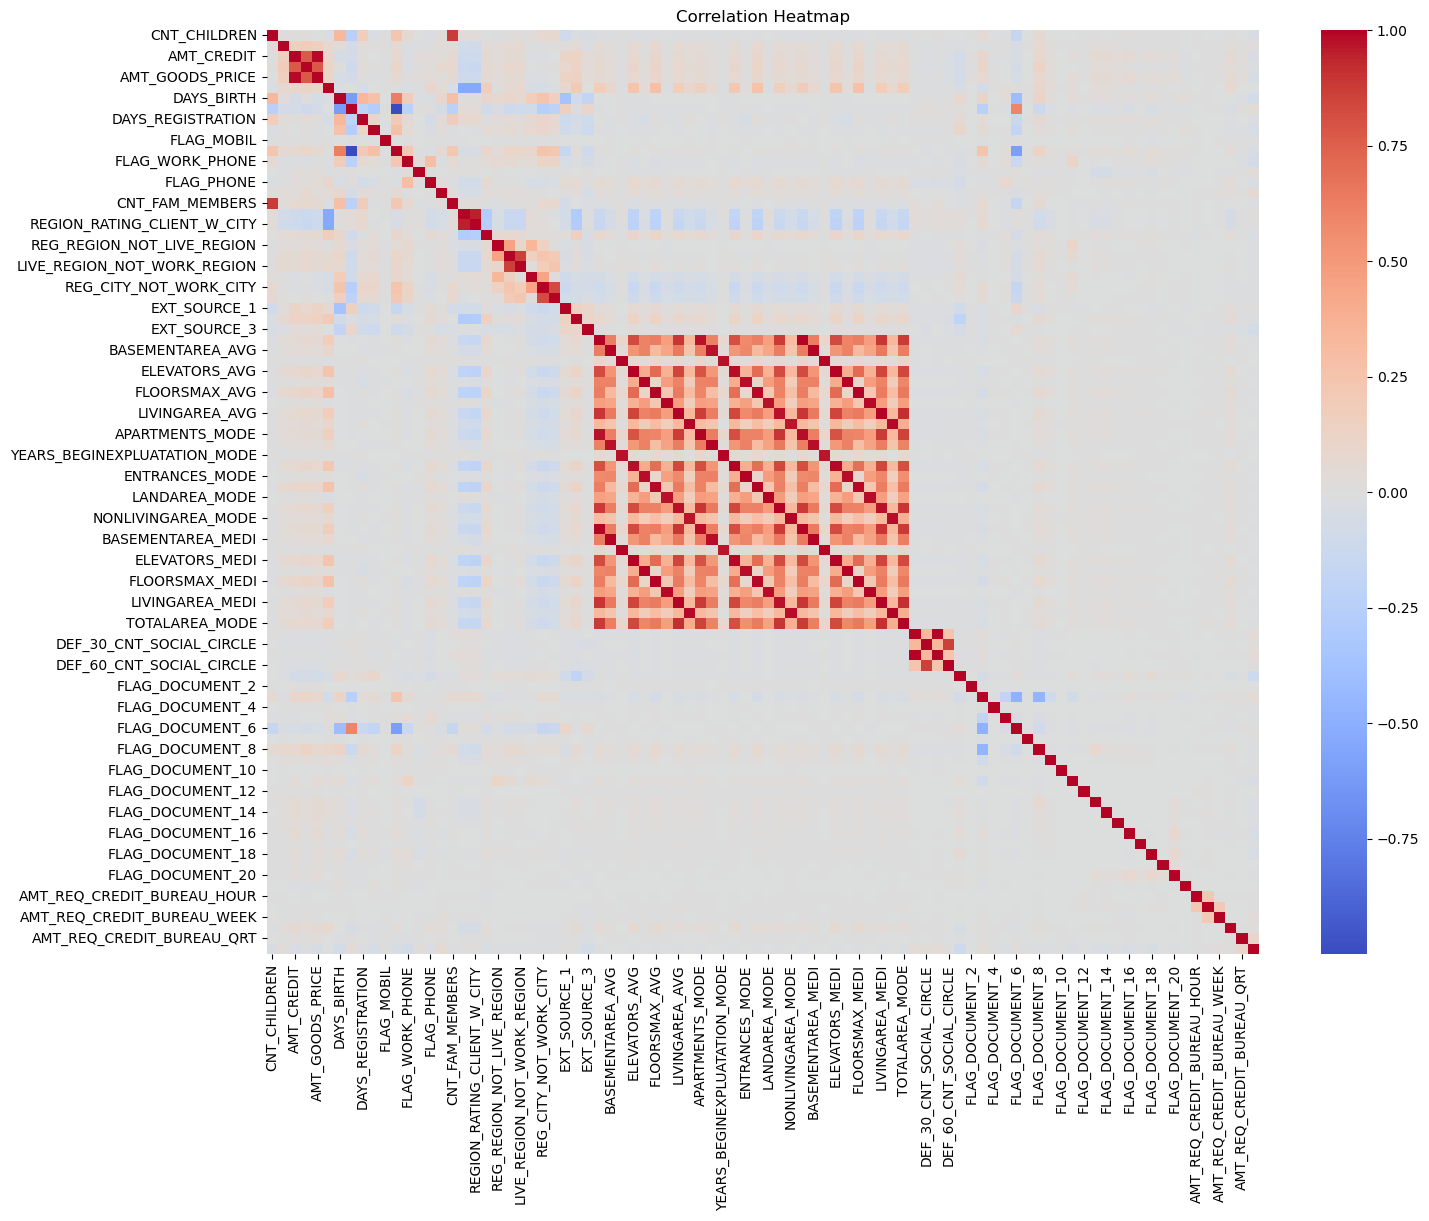

In [20]:
corr=app_train[num_cols].corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr,cmap='coolwarm',center=0)
plt.title('Correlation Heatmap')
plt.show()

In [21]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


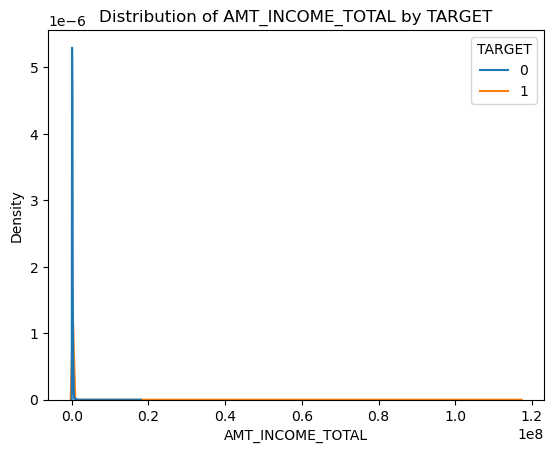

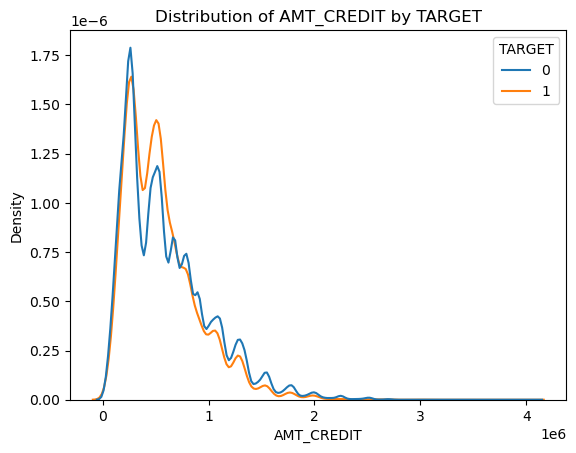

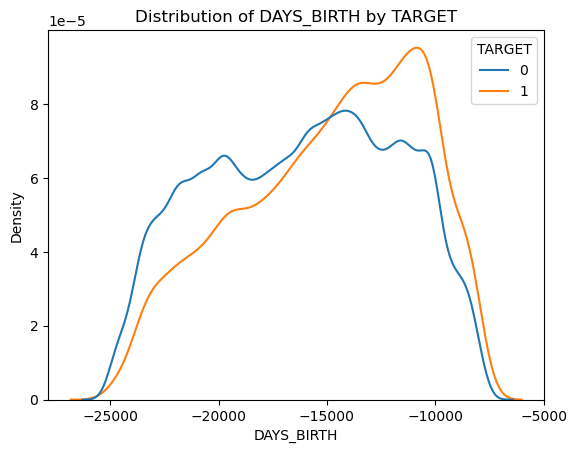

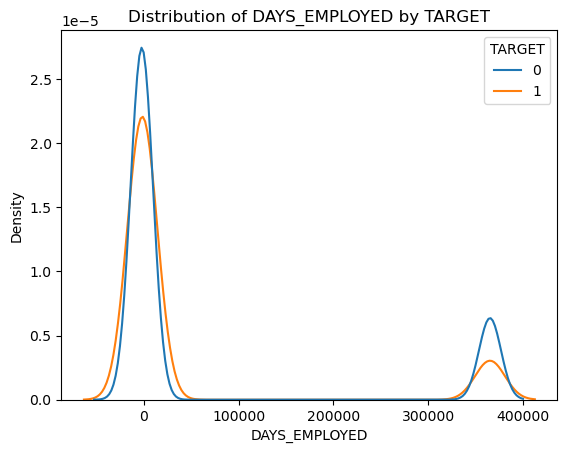

In [22]:
important=['AMT_INCOME_TOTAL','AMT_CREDIT','DAYS_BIRTH','DAYS_EMPLOYED']
for col in important:
    sns.kdeplot(data=app_train,x=col,hue='TARGET',common_norm=False)
    plt.title(f"Distribution of {col} by TARGET")
    plt.show()

In [23]:
missing_percent=app_train.isnull().mean()*100

In [24]:
drop_cols=missing_percent[missing_percent > 40].index.tolist()
print("\nDropping columns with >40% Missing:",drop_cols)
app_train_cleaned=app_train.drop(columns=drop_cols)


Dropping columns with >40% Missing: []


In [25]:
app_train_cleaned.to_csv(r"C:\Users\Admin\Downloads\application_train_cleaned.csv",index=False)

In [26]:
import os
os.getcwd()

'C:\\Users\\Admin\\Downloads'

In [27]:
bureau

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.0,0.0,0.0,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.0,0.0,0.0,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.0,0.0,0.0,Consumer credit,-1508,NaN


In [28]:
bureau_balance

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
...,...,...,...
27299920,5041336,-47,X
27299921,5041336,-48,X
27299922,5041336,-49,X
27299923,5041336,-50,X


In [29]:
print(bureau.shape)

(1716428, 17)


In [30]:
bureau_balance.shape

(27299925, 3)

In [31]:
bb_months=bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].agg(['min','max','count']).reset_index()
bb_months.columns=['SK_ID_BUREAU','MB_MIN','MB_MAX','MB_COUNT']

In [32]:
bb_status=bureau_balance.groupby(['SK_ID_BUREAU','STATUS']).size().unstack(fill_value=0).reset_index()
bb_status.columns=['SK_ID_BUREAU'] + [f'STATUS_{col}' for col in bb_status.columns[1:]] 

In [33]:
bb_agg=bb_months.merge(bb_status,on='SK_ID_BUREAU',how='left')

In [34]:
bureau_full=bureau.merge(bb_agg,on='SK_ID_BUREAU',how='left')

In [35]:
bureau.columns.tolist()

['SK_ID_CURR',
 'SK_ID_BUREAU',
 'CREDIT_ACTIVE',
 'CREDIT_CURRENCY',
 'DAYS_CREDIT',
 'CREDIT_DAY_OVERDUE',
 'DAYS_CREDIT_ENDDATE',
 'DAYS_ENDDATE_FACT',
 'AMT_CREDIT_MAX_OVERDUE',
 'CNT_CREDIT_PROLONG',
 'AMT_CREDIT_SUM',
 'AMT_CREDIT_SUM_DEBT',
 'AMT_CREDIT_SUM_LIMIT',
 'AMT_CREDIT_SUM_OVERDUE',
 'CREDIT_TYPE',
 'DAYS_CREDIT_UPDATE',
 'AMT_ANNUITY']

In [36]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({'AMT_CREDIT_SUM': ['mean', 'sum', 'max'],'CREDIT_DAY_OVERDUE': 'max'})

In [37]:
bureau_agg.columns = ['BUREAU_' + '_'.join(col).upper() for col in bureau_agg.columns]
bureau_agg.reset_index(inplace=True)

In [38]:
app_train = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')

In [39]:
app_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_CREDIT_DAY_OVERDUE_MAX
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,1.0,108131.945625,865055.565,450000.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,254350.125000,1017400.500,810000.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,94518.900000,189037.800,94537.8,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,146250.000000,146250.000,146250.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,1.0,0.0,0.0,1.0,0.0,1.0,990000.000000,3960000.000,2250000.0,0.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,45000.000000,45000.000,45000.0,0.0


In [40]:
prev_app

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,2300464,352015,Consumer loans,14704.290,267295.5,311400.0,0.0,267295.5,WEDNESDAY,12,...,Furniture,30.0,low_normal,POS industry with interest,365243.0,-508.0,362.0,-358.0,-351.0,0.0
1670210,2357031,334635,Consumer loans,6622.020,87750.0,64291.5,29250.0,87750.0,TUESDAY,15,...,Furniture,12.0,middle,POS industry with interest,365243.0,-1604.0,-1274.0,-1304.0,-1297.0,0.0
1670211,2659632,249544,Consumer loans,11520.855,105237.0,102523.5,10525.5,105237.0,MONDAY,12,...,Consumer electronics,10.0,low_normal,POS household with interest,365243.0,-1457.0,-1187.0,-1187.0,-1181.0,0.0
1670212,2785582,400317,Cash loans,18821.520,180000.0,191880.0,NaN,180000.0,WEDNESDAY,9,...,XNA,12.0,low_normal,Cash X-Sell: low,365243.0,-1155.0,-825.0,-825.0,-817.0,1.0


In [41]:
prev_agg=prev_app.groupby('SK_ID_CURR').agg({'AMT_ANNUITY':['mean','max'],'AMT_CREDIT':['mean','max'],
                                            'DAYS_DECISION':['mean','min','max']}).reset_index()

In [42]:
prev_agg

SK_ID_CURR   AMT_ANNUITY            AMT_CREDIT             \
                           mean        max       mean        max   
0          100001   3951.000000   3951.000   23787.00    23787.0   
1          100002   9251.775000   9251.775  179055.00   179055.0   
2          100003  56553.990000  98356.995  484191.00  1035882.0   
3          100004   5357.250000   5357.250   20106.00    20106.0   
4          100005   4813.200000   4813.200   20076.75    40153.5   
...           ...           ...        ...        ...        ...   
338852     456251   6605.910000   6605.910   40455.00    40455.0   
338853     456252  10074.465000  10074.465   56821.50    56821.5   
338854     456253   4770.405000   5567.715   20625.75    27306.0   
338855     456254  10681.132500  19065.825  134439.75   247423.5   
338856     456255  20775.391875  54022.140  424431.00  1271929.5   

       DAYS_DECISION              
                mean   min   max  
0          -1740.000 -1740 -1740  
1           -606.000  -606  -606  
2          -1305.000 -2341  -746  
3           -815.000  -815  -815  
4           -536.000  -757  -315  
...              ...   ...   ...  
338852      -273.000  -273  -273  
338853     -2497.000 -2497 -2497  
338854     -2380.000 -2851 -1909  
338855      -299.500  -322  -277  
338856      -587.625  -991  -171  

[338857 rows x 8 columns]

In [46]:
prev_agg.rename(columns={'SK_ID_CURR_':'SK_ID_CURR'},inplace=True)

In [47]:
prev_agg.columns=['_'.join(col).strip()
                 if type(col) is tuple else col for col in prev_agg.columns]


In [48]:
app_train = app_train.merge(prev_agg,on='SK_ID_CURR',how='left')

In [49]:
pos

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0
...,...,...,...,...,...,...,...,...
10001353,2448283,226558,-20,6.0,0.0,Active,843,0
10001354,1717234,141565,-19,12.0,0.0,Active,602,0
10001355,1283126,315695,-21,10.0,0.0,Active,609,0
10001356,1082516,450255,-22,12.0,0.0,Active,614,0


In [50]:
pos_agg=pos.groupby('SK_ID_CURR').agg({'MONTHS_BALANCE':['min','max','size']}).reset_index()

In [51]:
pos_agg.columns=['_'.join(col).strip()
                 if type(col) is tuple else col for col in pos_agg.columns]

In [52]:
pos_agg

,SK_ID_CURR_,MONTHS_BALANCE_min,MONTHS_BALANCE_max,MONTHS_BALANCE_size
0,100001,-96,-53,9
1,100002,-19,-1,19
2,100003,-77,-18,28
3,100004,-27,-24,4
4,100005,-25,-15,11
...,...,...,...,...
337247,456251,-9,-1,9
337248,456252,-82,-76,7
337249,456253,-96,-57,17
337250,456254,-11,-1,20


In [53]:
pos_agg.rename(columns={'SK_ID_CURR_':'SK_ID_CURR'},inplace=True)


In [54]:
app_train = app_train.merge(pos_agg,on='SK_ID_CURR',how='left')

In [55]:
installments

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585
...,...,...,...,...,...,...,...,...
13605396,2186857,428057,0.0,66,-1624.0,NaN,67.500,NaN
13605397,1310347,414406,0.0,47,-1539.0,NaN,67.500,NaN
13605398,1308766,402199,0.0,43,-7.0,NaN,43737.435,NaN
13605399,1062206,409297,0.0,43,-1986.0,NaN,67.500,NaN


In [56]:
ins_agg=installments.groupby('SK_ID_CURR').agg({'DAYS_INSTALMENT':['mean','max'],'AMT_PAYMENT':['mean','max']}).reset_index()

In [57]:
ins_agg.columns=['_'.join(col).strip()
                 if type(col) is tuple else col for col in ins_agg.columns]

In [58]:
ins_agg

,SK_ID_CURR_,DAYS_INSTALMENT_mean,DAYS_INSTALMENT_max,AMT_PAYMENT_mean,AMT_PAYMENT_max
0,100001,-2187.714286,-1619.0,5885.132143,17397.900
1,100002,-295.000000,-25.0,11559.247105,53093.745
2,100003,-1378.160000,-536.0,64754.586000,560835.360
3,100004,-754.000000,-724.0,7096.155000,10573.965
4,100005,-586.000000,-466.0,6240.205000,17656.245
...,...,...,...,...,...
339582,456251,-120.000000,-30.0,7492.924286,12815.010
339583,456252,-2391.000000,-2316.0,10069.867500,10074.465
339584,456253,-2372.928571,-1716.0,4115.915357,5575.185
339585,456254,-142.263158,-7.0,10239.832895,19065.825


In [59]:
ins_agg.rename(columns={'SK_ID_CURR_':'SK_ID_CURR'},inplace=True)

In [60]:
app_train =app_train.merge(ins_agg,on='SK_ID_CURR',how='left')

In [61]:
cc_agg=credit_card.groupby('SK_ID_CURR').agg({'MONTHS_BALANCE':['min','max','size'],
                                             'AMT_BALANCE':['mean','max']}).reset_index()

In [62]:
cc_agg.columns=['_'.join(col).strip()
                 if type(col) is tuple else col for col in cc_agg.columns]

In [63]:
cc_agg

,SK_ID_CURR_,MONTHS_BALANCE_min,MONTHS_BALANCE_max,MONTHS_BALANCE_size,AMT_BALANCE_mean,AMT_BALANCE_max
0,100006,-6,-1,6,0.000000,0.000
1,100011,-75,-2,74,54482.111149,189000.000
2,100013,-96,-1,96,18159.919219,161420.220
3,100021,-18,-2,17,0.000000,0.000
4,100023,-11,-4,8,0.000000,0.000
...,...,...,...,...,...,...
103553,456244,-41,-1,41,131834.730732,453627.675
103554,456246,-9,-2,8,13136.731875,43490.115
103555,456247,-96,-2,95,23216.396211,190202.130
103556,456248,-24,-2,23,0.000000,0.000


In [64]:
cc_agg.rename(columns={'SK_ID_CURR_':'SK_ID_CURR'},inplace=True)

In [65]:
app_train =app_train.merge(cc_agg,on='SK_ID_CURR',how='left')

In [66]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,MONTHS_BALANCE_size_x,DAYS_INSTALMENT_mean,DAYS_INSTALMENT_max,AMT_PAYMENT_mean,AMT_PAYMENT_max,MONTHS_BALANCE_min_y,MONTHS_BALANCE_max_y,MONTHS_BALANCE_size_y,AMT_BALANCE_mean,AMT_BALANCE_max
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,19.0,-295.000000,-25.0,11559.247105,53093.745,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,28.0,-1378.160000,-536.0,64754.586000,560835.360,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,4.0,-754.000000,-724.0,7096.155000,10573.965,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,21.0,-252.250000,-11.0,62947.088438,691786.890,-6.0,-1.0,6.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,66.0,-1028.606061,-14.0,12214.060227,22678.785,NaN,NaN,NaN,NaN,NaN


In [68]:
app_train.isnull().sum().sort_values(ascending=False).head(20)

AMT_BALANCE_max                  220606
AMT_BALANCE_mean                 220606
MONTHS_BALANCE_size_y            220606
MONTHS_BALANCE_max_y             220606
MONTHS_BALANCE_min_y             220606
BUREAU_AMT_CREDIT_SUM_MEAN        44021
BUREAU_AMT_CREDIT_SUM_MAX         44021
BUREAU_CREDIT_DAY_OVERDUE_MAX     44020
BUREAU_AMT_CREDIT_SUM_SUM         44020
MONTHS_BALANCE_size_x             18067
MONTHS_BALANCE_max_x              18067
MONTHS_BALANCE_min_x              18067
AMT_ANNUITY_mean                  16871
AMT_ANNUITY_max                   16871
DAYS_DECISION_max                 16454
DAYS_DECISION_min                 16454
DAYS_DECISION_mean                16454
AMT_CREDIT_max                    16454
AMT_CREDIT_mean                   16454
AMT_PAYMENT_max                   15876
dtype: int64

In [69]:
app_train=app_train.drop(columns=['SK_ID_CURR'])

In [70]:
type(app_train)

pandas.core.frame.DataFrame

In [71]:
app_train.shape

(307511, 127)

In [72]:
high_null_cols=[col for col in app_train.columns if
               app_train[col].isnull().mean()>0.9]
if high_null_cols:
    app_train.drop(columns=high_null_cols,inplace=True)
else:
    app_train.drop(columns=high_null_cols,inplace=True)
    


In [73]:
for col in app_train.select_dtypes(include=['float64','int64']):
    app_train[col]=app_train[col].fillna(app_train[col].median())

In [74]:
for col in app_train.select_dtypes(include=['object']):
    app_train[col]=app_train[col].fillna('Unknown')

In [75]:
type(app_train)

pandas.core.frame.DataFrame

In [76]:
app_train.shape

(307511, 127)

In [77]:
app_train.isnull().sum()

TARGET                   0
NAME_CONTRACT_TYPE       0
CODE_GENDER              0
FLAG_OWN_CAR             0
FLAG_OWN_REALTY          0
                        ..
MONTHS_BALANCE_min_y     0
MONTHS_BALANCE_max_y     0
MONTHS_BALANCE_size_y    0
AMT_BALANCE_mean         0
AMT_BALANCE_max          0
Length: 127, dtype: int64

In [78]:
app_train=pd.get_dummies(app_train,drop_first=True)

In [79]:
app_train.head()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,ORGANIZATION_TYPE_XNA,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes
0,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,-3648.0,...,False,False,False,False,False,False,False,True,False,False
1,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,-1186.0,...,False,False,False,False,False,False,False,False,False,False
2,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,-4260.0,...,False,False,False,False,False,False,True,False,False,False
3,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,-9833.0,...,False,False,False,False,False,False,True,False,False,False
4,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,-4311.0,...,False,False,False,False,False,False,True,False,False,False


In [80]:
from sklearn.preprocessing import StandardScaler
exclude_cols=['SK_ID_CURR','TARGET']
numeric_cols=[col for col in app_train.select_dtypes(include=['number']).columns
             if col not in exclude_cols]
scaler=StandardScaler()
app_train[numeric_cols]=scaler.fit_transform(app_train[numeric_cols])

In [81]:
app_train.head()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,ORGANIZATION_TYPE_XNA,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes
0,1,-0.577538,0.142129,-0.478095,-0.166143,-0.507236,-0.149452,1.506880,-0.456215,0.379837,...,False,False,False,False,False,False,False,True,False,False
1,0,-0.577538,0.426792,1.725450,0.592683,1.600873,-1.252750,-0.166821,-0.460115,1.078697,...,False,False,False,False,False,False,False,False,False,False
2,0,-0.577538,-0.427196,-1.152888,-1.404669,-1.092145,-0.783451,-0.689509,-0.453299,0.206116,...,False,False,False,False,False,False,True,False,False,False
3,0,-0.577538,-0.142533,-0.711430,0.177874,-0.653463,-0.928991,-0.680114,-0.473217,-1.375829,...,False,False,False,False,False,False,True,False,False,False
4,0,-0.577538,-0.199466,-0.213734,-0.361749,-0.068554,0.563570,-0.892535,-0.473210,0.191639,...,False,False,False,False,False,False,True,False,False,False


## **Model Building** ##

In [82]:
x=app_train.drop(['TARGET'],axis=1)
y=app_train['TARGET']

In [83]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)


In [84]:
!pip install imbalanced-learn
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
pca = PCA(n_components=50)  
x_train_reduced = pca.fit_transform(x_train)
x_test_reduced=pca.transform(x_test)

smote = SMOTE(random_state=42)
x_train_bal, y_train_bal = smote.fit_resample(x_train_reduced, y_train)
print("before smote:",y_train.value_counts())
print("after smote:",y_train_bal.value_counts())


C:\Users\Admin\anaconda3\envs\mlproj\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


before smote: TARGET
0    226148
1     19860
Name: count, dtype: int64
after smote: TARGET
0    226148
1    226148
Name: count, dtype: int64


In [85]:
y_train_bal.value_counts()

TARGET
0    226148
1    226148
Name: count, dtype: int64

## **Logistic Regression** ##

In [86]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000,random_state=42)
lr.fit(x_train_bal,y_train_bal)

LogisticRegression(max_iter=1000, random_state=42)

In [87]:
y_pred=lr.predict(x_test_reduced)
y_pred

array([0, 0, 1, ..., 0, 1, 1], dtype=int64)

In [88]:
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.25      4965

    accuracy                           0.68     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.89      0.68      0.76     61503



In [89]:
print(accuracy_score(y_test,y_pred))

0.6842593044241745


In [90]:
from sklearn.metrics import recall_score
recall=recall_score(y_test,y_pred)
print(f"Recall Score:{recall:.2f}")

Recall Score:0.67


In [91]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay
y_pred=lr.predict(x_test_reduced)
y_proba=lr.predict_proba(x_test_reduced)[:,1]

In [92]:
y_proba

array([0.33302127, 0.37200819, 0.68410015, ..., 0.48932734, 0.55359221,
       0.50603681])

In [93]:
print("ROC-AUC Score:",roc_auc_score(y_test,y_proba))

ROC-AUC Score: 0.737198615929676


## **Decision Tree Classifier** ##

In [94]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train_bal,y_train_bal)

DecisionTreeClassifier()

In [95]:
y_pred_dt=dt_model.predict(x_test_reduced)
y_pred_dt

array([0, 1, 0, ..., 1, 0, 1], dtype=int64)

In [96]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.77      0.84     56538
           1       0.12      0.35      0.18      4965

    accuracy                           0.74     61503
   macro avg       0.53      0.56      0.51     61503
weighted avg       0.87      0.74      0.79     61503



In [97]:
accuracy_dt=accuracy_score(y_test,y_pred_dt)
print("Decision Tree Acurracy:",accuracy_dt)

Decision Tree Acurracy: 0.737069736435621


In [98]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay
y_pred_dt=dt_model.predict(x_test_reduced)
y_proba_dt=dt_model.predict_proba(x_test_reduced)[:,1]

In [99]:
y_proba_dt

array([0., 1., 0., ..., 1., 0., 1.])

In [100]:
print("ROC-AUC Score:",roc_auc_score(y_test,y_proba_dt))

ROC-AUC Score: 0.5625744426201494


## **Random Forest Classifier** ##

In [101]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=200,random_state=42)
rf_model.fit(x_train_bal,y_train_bal)

RandomForestClassifier(n_estimators=200, random_state=42)

In [102]:
y_pred_rf=rf_model.predict(x_test_reduced)
y_pred_rf

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [103]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(classification_report(y_test,y_pred_rf)) 

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     56538
           1       0.21      0.22      0.22      4965

    accuracy                           0.87     61503
   macro avg       0.57      0.57      0.57     61503
weighted avg       0.87      0.87      0.87     61503



In [105]:
accuracy_rf=accuracy_score(y_test,y_pred_rf)
print("Random Forest:",accuracy_rf)

Random Forest: 0.8705591597157862


In [106]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay
y_pred_rf=rf_model.predict(x_test_reduced)
y_proba_rf=rf_model.predict_proba(x_test_reduced)[:,1]

In [107]:
y_proba_rf

array([0.21 , 0.44 , 0.315, ..., 0.27 , 0.445, 0.38 ])

In [108]:
print("ROC-AUC Score:",roc_auc_score(y_test,y_proba_dt))

ROC-AUC Score: 0.5625744426201494


## **XGB Classifier** ## 

In [109]:
import xgboost as xgb

In [110]:
model=xgb.XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth=3,use_label_encoder=False,eval_metric='logloss')
model.fit(x_train,y_train)

C:\Users\Admin\anaconda3\envs\mlproj\lib\site-packages\xgboost\core.py:158: UserWarning: [17:36:03] WARNING: D:\bld\xgboost-split_1744329010901\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [111]:
y_pred_xgb=model.predict(x_test)
y_pred_xgb

array([0, 0, 0, ..., 0, 0, 0])

In [112]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.64      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.78      0.51      0.50     61503
weighted avg       0.90      0.92      0.88     61503



In [113]:
accuracy_xgb= accuracy_score(y_test,y_pred_xgb)
print("xgb:",accuracy_xgb)

xgb: 0.9199226054013625


In [114]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay
y_pred_xgb=model.predict(x_test)
y_proba_xgb=model.predict_proba(x_test)[:,1]

In [115]:
y_proba_xgb

array([0.03458924, 0.03620851, 0.20630611, ..., 0.05916085, 0.20134251,
       0.11740797], dtype=float32)

In [116]:
print("ROC-AUC Score:",roc_auc_score(y_test,y_proba_xgb))

ROC-AUC Score: 0.7661919278096415


## **Results** ##

In [117]:
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "ROC AUC": roc_auc_score(y_test, y_proba_dt)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "ROC AUC": roc_auc_score(y_test, y_proba_rf)
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "ROC AUC": roc_auc_score(y_test, y_proba_xgb)
    }
]

In [118]:
results=pd.DataFrame(results)
print(results)

                 Model  Accuracy   ROC AUC
0  Logistic Regression  0.684259  0.737199
1        Decision Tree  0.737070  0.562574
2        Random Forest  0.870559  0.709545
3              XGBoost  0.919923  0.766192



# **Final Report**

This project addresses the **Home Loan Default Prediction (PRCP-1006)** problem.  
The tasks were:

1. **Data Analysis** – Performed exploratory data analysis (EDA) on the provided datasets including application data, bureau data, credit card balance, previous applications, installments, and POS cash balance data.  
2. **Predictive Modeling** – Developed machine learning models to predict loan default. Models tested include Logistic Regression, Random Forest, Gradient Boosting, and XGBoost.  
3. **Model Comparison** – Evaluated models using metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC.  

The analysis revealed that feature engineering (aggregating bureau and credit history data, handling categorical features, and managing missing values) played a key role in improving performance.



# **Conclusions**

- The project successfully built a pipeline for data cleaning, feature engineering, and predictive modeling.  
- Among the tested models, **XGBoost/Gradient Boosting** performed best in terms of ROC-AUC and recall, making it the most suitable for production deployment.  
- Feature importance analysis shows that previous repayment behavior, credit history length, and installment patterns are strong indicators of loan default.  
- Handling missing data, encoding categorical variables, and scaling numeric features improved model stability.  



# **Challenges Faced**

1. **Large Dataset Integration** – Combining multiple tables (`application_train`, `bureau`, `previous_application`, etc.) required careful merging and aggregation to avoid data leakage.  
2. **Class Imbalance** – Defaulters were significantly fewer than non-defaulters. Techniques like **SMOTE**, **undersampling**, and **class weights** were applied.  
3. **Missing Values** – Many features had a high percentage of missing values; imputation strategies and feature selection were necessary.  
4. **High Dimensionality** – Feature space was very large after encoding; feature selection and dimensionality reduction improved efficiency.  
5. **Computation Cost** – Training complex models like XGBoost on the full dataset required optimization and sampling strategies.  

These challenges were addressed systematically, ensuring a balanced and interpretable model for predicting loan defaults.
